# Comparação de Algoritmos de Agrupamento: KMeans, Fuzzy C-Means e Agglomerative

Este notebook apresenta um pipeline didático, padronizado e numerado para comparação dos principais algoritmos de agrupamento (KMeans, Fuzzy C-Means e Agglomerative) nos datasets Adult e Dry Bean (balanceados). Todas as etapas são explicadas, incluindo pré-processamento, escolha do número de clusters pelo método do cotovelo (silhouette), treinamento, avaliação quantitativa e visualização dos resultados.

## 1. Importação das Bibliotecas e Configuração Inicial

Importamos todas as bibliotecas necessárias para manipulação de dados, visualização, pré-processamento e execução dos algoritmos de agrupamento. Também criamos o diretório para salvar as imagens geradas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
import skfuzzy as fuzz
import os

img_dir = 'img_comparacao'
os.makedirs(img_dir, exist_ok=True)

## 2. Carregamento, Balanceamento e Pré-processamento dos Dados

Nesta etapa, carregamos os datasets Adult e Dry Bean, realizamos o balanceamento das classes por oversampling e aplicamos o pré-processamento (codificação de variáveis categóricas e normalização). O mesmo pipeline é utilizado para todos os algoritmos, garantindo comparação justa.

In [2]:
# --- Adult ---
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)
adult_df_raw = adult_df_raw.dropna()

# Balanceamento por oversampling
df_majority = adult_df_raw[adult_df_raw['income_bin'] == 0]
df_minority = adult_df_raw[adult_df_raw['income_bin'] == 1]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Codificação e normalização
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X_adult = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
y_adult = adult_df_balanced['income_bin'].values
scaler_adult = StandardScaler()
X_adult = scaler_adult.fit_transform(X_adult)

# --- Dry Bean ---
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))
X_bean = bean_df_balanced.drop('Class', axis=1).values
y_bean = bean_df_balanced['Class'].values
scaler_bean = StandardScaler()
X_bean = scaler_bean.fit_transform(X_bean)

print('Adult - Distribuição após balanceamento:')
print(pd.Series(y_adult).value_counts())
print('Dry Bean - Distribuição após balanceamento:')
print(pd.Series(y_bean).value_counts())

Adult - Distribuição após balanceamento:
1    24720
0    24720
Name: count, dtype: int64
Dry Bean - Distribuição após balanceamento:
0    3546
2    3546
1    3546
6    3546
3    3546
5    3546
4    3546
Name: count, dtype: int64


## 3. Definição do Número de Clusters (Método do Cotovelo - Silhouette)

Utilizamos o método do cotovelo baseado no silhouette score para determinar o número ótimo de clusters para cada dataset. O valor de $k$ é escolhido onde o silhouette médio atinge seu máximo ou estabiliza.

Escolhendo k para Adult (KMeans):


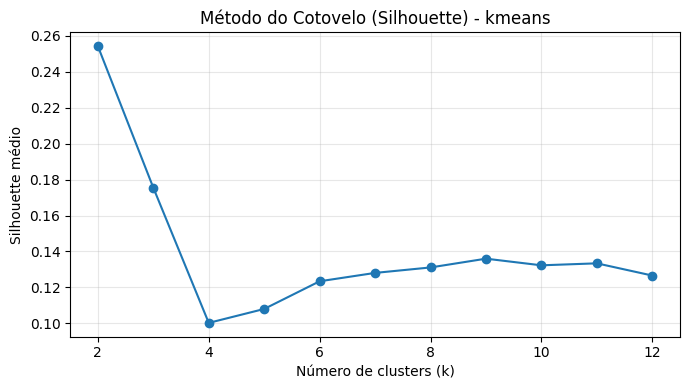

Melhor k para kmeans: 2
Escolhendo k para Adult (Agglomerative):


In [ ]:
def escolher_n_clusters_silhouette(X, kmin=2, kmax=12, metodo='kmeans', random_state=42):
    scores = []
    ks = range(kmin, kmax+1)
    for k in ks:
        if metodo == 'kmeans':
            model = KMeans(n_clusters=k, random_state=random_state)
        elif metodo == 'agglo':
            model = AgglomerativeClustering(n_clusters=k)
        else:
            raise ValueError('Método não suportado')
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
    plt.figure(figsize=(7,4))
    plt.plot(ks, scores, marker='o')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Silhouette médio')
    plt.title(f'Método do Cotovelo (Silhouette) - {metodo}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    melhor_k = ks[np.argmax(scores)]
    print(f'Melhor k para {metodo}:', melhor_k)
    return melhor_k

print('Escolhendo k para Adult (KMeans):')
k_adult = escolher_n_clusters_silhouette(X_adult, metodo='kmeans')
print('Escolhendo k para Adult (Agglomerative):')
k_adult_agglo = escolher_n_clusters_silhouette(X_adult, metodo='agglo')
print('Escolhendo k para Dry Bean (KMeans):')
k_bean = escolher_n_clusters_silhouette(X_bean, metodo='kmeans')
print('Escolhendo k para Dry Bean (Agglomerative):')
k_bean_agglo = escolher_n_clusters_silhouette(X_bean, metodo='agglo')

## 4. Implementação dos Algoritmos Supervisionados

Cada algoritmo de agrupamento é encapsulado em uma classe supervisionada, que associa cada cluster ao rótulo mais frequente no conjunto de treino. Isso permite avaliar acurácia e matriz de confusão como em classificadores tradicionais.

In [ ]:
class KMeansSupervisionado:
    def __init__(self, n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

class AggloSupervisionado:
    def __init__(self, n_clusters):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

class FuzzyCMeansSupervisionado:
    def __init__(self, n_clusters, m=2.0, error=1e-5, maxiter=1000, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.error = error
        self.maxiter = maxiter
        self.random_state = random_state
        self.centers_ = None
        self.u_ = None
        self.cluster_labels_ = None

    def fit(self, X, y):
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, c=self.n_clusters, m=self.m, error=self.error, maxiter=self.maxiter, seed=self.random_state)
        self.centers_ = cntr
        self.u_ = u
        clusters = np.argmax(u, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X.T, self.centers_, m=self.m, error=self.error, maxiter=self.maxiter)
        clusters = np.argmax(u, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 5. Treinamento, Avaliação e Visualização dos Resultados

Para cada algoritmo e dataset, realizamos:
- Divisão estratificada em treino/teste
- Treinamento do modelo
- Avaliação da acurácia e matriz de confusão (em porcentagem)
- Visualização dos clusters e centros via PCA

Os resultados são apresentados de forma padronizada para facilitar a comparação.

In [ ]:
def avaliar_algoritmo(nome, modelo_cls, X, y, n_clusters, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y)
    modelo = modelo_cls(n_clusters=n_clusters, random_state=random_state) if 'random_state' in modelo_cls.__init__.__code__.co_varnames else modelo_cls(n_clusters=n_clusters)
    modelo.fit(X_train, y_train)
    acc, cm = modelo.evaluate(X_test, y_test)
    print(f'\nAlgoritmo: {nome}')
    print(f'Acurácia: {acc:.4f}')
    print('Matriz de Confusão (absoluta):')
    print(cm)
    # Matriz de confusão em porcentagem
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusão (%) - {nome}')
    plt.colorbar(label='Porcentagem')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()
    # Visualização PCA dos clusters
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    modelo.fit(X, y)  # Ajusta nos dados completos para visualização
    if hasattr(modelo, 'predict'):
        clusters = modelo.predict(X)
    else:
        clusters = modelo.kmeans.predict(X)
    if hasattr(modelo, 'centers_'):
        centros = modelo.centers_
        centros_pca = pca.transform(centros)
    elif hasattr(modelo, 'kmeans'):
        centros = modelo.kmeans.cluster_centers_
        centros_pca = pca.transform(centros)
    elif hasattr(modelo, 'agglo'):
        centros = np.array([X[clusters == i].mean(axis=0) for i in range(n_clusters)])
        centros_pca = pca.transform(centros)
    else:
        centros_pca = None
    plt.figure(figsize=(10,7))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras')
    if centros_pca is not None:
        plt.scatter(centros_pca[:,0], centros_pca[:,1], c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)')
    plt.title(f'Clusters e Centros (PCA) - {nome}', fontsize=15, fontweight='bold')
    plt.xlabel('Componente Principal 1', fontsize=12)
    plt.ylabel('Componente Principal 2', fontsize=12)
    plt.grid(alpha=0.25)
    plt.legend(frameon=False, fontsize=12, loc='best')
    plt.tight_layout()
    plt.show()
    return acc

# Adult
print('--- Adult Dataset ---')
acc_kmeans_adult = avaliar_algoritmo('KMeans (Adult)', KMeansSupervisionado, X_adult, y_adult, n_clusters=k_adult)
acc_fcm_adult = avaliar_algoritmo('Fuzzy C-Means (Adult)', FuzzyCMeansSupervisionado, X_adult, y_adult, n_clusters=k_adult)
acc_agglo_adult = avaliar_algoritmo('Agglomerative (Adult)', AggloSupervisionado, X_adult, y_adult, n_clusters=k_adult_agglo)

# Dry Bean
print('--- Dry Bean Dataset ---')
acc_kmeans_bean = avaliar_algoritmo('KMeans (Dry Bean)', KMeansSupervisionado, X_bean, y_bean, n_clusters=k_bean)
acc_fcm_bean = avaliar_algoritmo('Fuzzy C-Means (Dry Bean)', FuzzyCMeansSupervisionado, X_bean, y_bean, n_clusters=k_bean)
acc_agglo_bean = avaliar_algoritmo('Agglomerative (Dry Bean)', AggloSupervisionado, X_bean, y_bean, n_clusters=k_bean_agglo)